In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import List
from scipy.spatial import Delaunay
from scipy.interpolate import CubicSpline

c0 = 299_792_458.0
mu0 = 4e-7 * np.pi
eps0 = 1.0 / (mu0 * c0**2)
eta0 = np.sqrt(mu0 / eps0)

In [2]:
def norm(v, axis=-1, keepdims=False):
    return np.linalg.norm(v, axis=axis, keepdims=keepdims)


def unit(v, axis=-1):
    v = np.asarray(v, dtype=float)
    n = norm(v, axis=axis, keepdims=True)
    n = np.where(n < 1e-15, 1.0, n)
    return v / n


def dot(a, b, axis=-1):
    return np.sum(a * b, axis=axis)


def cross(a, b):
    return np.cross(a, b)


def refract_vector(I, N, n1, n2):
    """
    Robust 3D Snell refraction.

    I: incident unit direction, along ray propagation
    N: surface normal, arbitrary orientation
    n1: incident refractive index
    n2: transmitted refractive index
    """
    I = unit(np.asarray(I).reshape(1, 3))[0]
    N = unit(np.asarray(N).reshape(1, 3))[0]

    # Make normal oppose incident ray
    if dot(I, N) > 0:
        N = -N

    eta = n1 / n2
    cos_i = -dot(N, I)

    sin_t2 = eta**2 * (1.0 - cos_i**2)

    if sin_t2 > 1.0:
        return None, False

    cos_t = np.sqrt(1.0 - sin_t2)

    T = eta * I + (eta * cos_i - cos_t) * N
    T = unit(T.reshape(1, 3))[0]

    return T, True


def spherical_directions(n_theta=41, n_phi=81, hemisphere="upper"):
    if hemisphere == "upper":
        theta = np.linspace(0.0, np.pi / 3, n_theta)
    else:
        theta = np.linspace(0.0, np.pi, n_theta)

    phi = np.linspace(0.0, 2 * np.pi, n_phi, endpoint=False)

    TH, PH = np.meshgrid(theta, phi, indexing="ij")

    x = np.sin(TH) * np.cos(PH)
    y = np.sin(TH) * np.sin(PH)
    z = np.cos(TH)

    dirs = np.stack([x, y, z], axis=-1).reshape(-1, 3)
    return unit(dirs)

In [3]:
@dataclass
class Ray:
    r0: np.ndarray
    k_hat: np.ndarray
    phase: float = 0.0
    amp: float = 1.0
    alive: bool = True
    medium_index: int = 0
    history: List[np.ndarray] = field(default_factory=list)
    normals: List[np.ndarray] = field(default_factory=list)


@dataclass
class Surface:
    name: str
    eps_r_above: float
    eps_r_below: float

    def z(self, x, y):
        raise NotImplementedError

    def dzdx(self, x, y):
        raise NotImplementedError

    def dzdy(self, x, y):
        raise NotImplementedError

    def normal(self, x, y):
        fx = self.dzdx(x, y)
        fy = self.dzdy(x, y)

        n = np.stack([-fx, -fy, np.ones_like(fx)], axis=-1)
        return unit(n)


@dataclass
class ConicSurface(Surface):
    c: float
    K: float
    z0: float

    def z(self, x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        r2 = x**2 + y**2
        root = 1.0 - (1.0 + self.K) * self.c**2 * r2
        root = np.maximum(root, 1e-14)

        return self.z0 + (self.c * r2) / (1.0 + np.sqrt(root))

    def dzdx(self, x, y):
        h = 1e-7
        return (self.z(x + h, y) - self.z(x - h, y)) / (2 * h)

    def dzdy(self, x, y):
        h = 1e-7
        return (self.z(x, y + h) - self.z(x, y - h)) / (2 * h)


@dataclass
class PlaneSurface(Surface):
    z_plane: float

    def z(self, x, y):
        return np.full_like(np.asarray(x), self.z_plane, dtype=float)

    def dzdx(self, x, y):
        return np.zeros_like(np.asarray(x), dtype=float)

    def dzdy(self, x, y):
        return np.zeros_like(np.asarray(x), dtype=float)
    
@dataclass
class PointDefinedRadialSurface4(Surface):
    rz_points: np.ndarray   # shape (4,2)

    def __post_init__(self):
        pts = np.asarray(self.rz_points, dtype=float)

        if pts.shape != (4, 2):
            raise ValueError("rz_points must have shape (4,2)")

        # Sort by radius
        pts = pts[np.argsort(pts[:, 0])]

        self.r_pts = pts[:, 0]
        self.z_pts = pts[:, 1]

        # Build cubic spline
        self.spline = CubicSpline(
            self.r_pts,
            self.z_pts,
            bc_type="natural",
            extrapolate=True
        )

    def z(self, x, y):
        r = np.sqrt(np.asarray(x)**2 + np.asarray(y)**2)
        return self.spline(r)

    def dzdr(self, r):
        return self.spline.derivative()(r)

    def dzdx(self, x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        r = np.sqrt(x**2 + y**2)
        r_safe = np.where(r < 1e-14, 1.0, r)

        return self.dzdr(r) * x / r_safe

    def dzdy(self, x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        r = np.sqrt(x**2 + y**2)
        r_safe = np.where(r < 1e-14, 1.0, r)

        return self.dzdr(r) * y / r_safe

In [4]:
@dataclass
class ArrayElement:
    position: np.ndarray
    phase_exc: float = 0.0
    amp_exc: float = 1.0


@dataclass
class ArrayAntenna:
    elements: List[ArrayElement]

    def positions(self):
        return np.array([e.position for e in self.elements])


def build_rect_array(nx=4, ny=4, dx=0.5, dy=0.5, wavelength=1.0, z0=0.0):
    xs = (np.arange(nx) - (nx - 1) / 2) * dx * wavelength
    ys = (np.arange(ny) - (ny - 1) / 2) * dy * wavelength

    elems = []

    for x in xs:
        for y in ys:
            elems.append(
                ArrayElement(
                    position=np.array([x, y, z0], dtype=float)
                )
            )

    return ArrayAntenna(elems)


def gaussian_element_pattern(k_hat, q=2.0):
    cos_theta = np.clip(k_hat[..., 2], 0.0, 1.0)
    return cos_theta**q

In [5]:
@dataclass
class LensSystem:
    surfaces: List[Surface]
    medium_eps: List[float]

    def refractive_index(self, region_id):
        return np.sqrt(self.medium_eps[region_id])

In [6]:
def intersect_ray_surface(
    ray_origin,
    ray_dir,
    surface,
    t_min=1e-6,
    t_max=1.0,
    n_steps=500
):
    """
    Intersect ray r(t)=r0+t*k with surface z=f(x,y).
    """

    ray_origin = np.asarray(ray_origin, dtype=float)
    ray_dir = unit(np.asarray(ray_dir).reshape(1, 3))[0]

    x0, y0, z0 = ray_origin
    dx, dy, dz = ray_dir

    ts = np.linspace(t_min, t_max, n_steps)

    xs = x0 + ts * dx
    ys = y0 + ts * dy
    zs = z0 + ts * dz

    fs = zs - surface.z(xs, ys)

    idx = np.where(np.sign(fs[:-1]) * np.sign(fs[1:]) <= 0)[0]

    if len(idx) == 0:
        return None, None, None

    i = idx[0]

    a = ts[i]
    b = ts[i + 1]

    for _ in range(60):
        m = 0.5 * (a + b)

        xa = x0 + a * dx
        ya = y0 + a * dy
        za = z0 + a * dz
        fa = za - surface.z(np.array([xa]), np.array([ya]))[0]

        xm = x0 + m * dx
        ym = y0 + m * dy
        zm = z0 + m * dz
        fm = zm - surface.z(np.array([xm]), np.array([ym]))[0]

        if fa * fm <= 0:
            b = m
        else:
            a = m

    t_hit = 0.5 * (a + b)
    p_hit = ray_origin + t_hit * ray_dir

    n_hit = surface.normal(
        np.array([p_hit[0]]),
        np.array([p_hit[1]])
    )[0]

    return t_hit, p_hit, n_hit

In [7]:
def trace_ray_through_lens(ray, lens, k0, t_max=1.0):
    """
    Sequentially trace a ray through ordered lens interfaces.
    """

    r = ray.r0.copy()
    k_hat = unit(ray.k_hat.reshape(1, 3))[0]
    phase = ray.phase

    hist = [r.copy()]
    normals = []

    region = ray.medium_index

    for surf in lens.surfaces:
        t_hit, p_hit, n_geom = intersect_ray_surface(
            r,
            k_hat,
            surf,
            t_max=t_max
        )

        if p_hit is None:
            return None

        ds = norm(p_hit - r)
        n_med = lens.refractive_index(region)
        phase += k0 * n_med * ds

        next_region = region + 1

        if next_region >= len(lens.medium_eps):
            return None

        n1 = lens.refractive_index(region)
        n2 = lens.refractive_index(next_region)

        T, valid = refract_vector(
            I=k_hat,
            N=n_geom,
            n1=n1,
            n2=n2
        )

        if not valid:
            return None

        hist.append(p_hit.copy())
        normals.append(n_geom.copy())

        r = p_hit + 1e-6 * T
        k_hat = T
        region = next_region

    return Ray(
        r0=r,
        k_hat=k_hat,
        phase=phase,
        amp=ray.amp,
        alive=True,
        medium_index=region,
        history=hist,
        normals=normals
    )

In [8]:
def wrap_phase(phi):
    return np.angle(np.exp(1j * phi))


def nearest_array_element(array_positions, point):
    """
    Return index of nearest array element to a point.
    """
    d = norm(array_positions - point[None, :], axis=1)
    return np.argmin(d), np.min(d)


def phase_average(phases):
    """
    Average phases correctly using complex phasor average.
    """
    if len(phases) == 0:
        return 0.0

    z = np.mean(np.exp(1j * np.asarray(phases)))
    return np.angle(z)

In [9]:
def reverse_ray_tracing(
    array,
    lens,
    wavelength,
    scan_dir,
    ref_plane_z=0.12,
    x_range=(-0.07, 0.07),
    y_range=(-0.07, 0.07),
    nx=81,
    ny=81,
    t_max=1.0,
    target_z=0.0,
    max_element_distance=None,
    verbose=True
):
    """
    Corrected reverse ray tracing phase assignment.

    Instead of launching one ray per array element, this function:

    1. Launches a grid of reverse rays from the reference plane.
    2. Traces them through the lens.
    3. Lets them naturally continue to z = target_z.
    4. Maps each arriving ray to the nearest array element.
    5. Assigns each element phase using averaged optical path phase.

    This avoids the incorrect vertical mapping:
        element (x,y) <-> reference-plane point (x,y)
    """

    reverse_lens = LensSystem(
        surfaces=list(reversed(lens.surfaces)),
        medium_eps=list(reversed(lens.medium_eps))
    )

    k0 = 2 * np.pi / wavelength
    scan_dir = unit(np.asarray(scan_dir).reshape(1, 3))[0]

    array_pos = array.positions()

    if max_element_distance is None:
        # Estimate a reasonable capture radius from array spacing
        if len(array_pos) > 1:
            dmat = norm(array_pos[:, None, :] - array_pos[None, :, :], axis=2)
            dmat[dmat == 0] = np.inf
            min_spacing = np.min(dmat)
            max_element_distance = 0.55 * min_spacing
        else:
            max_element_distance = wavelength / 2

    xs = np.linspace(x_range[0], x_range[1], nx)
    ys = np.linspace(y_range[0], y_range[1], ny)

    phase_bins = [[] for _ in array.elements]
    path_bins = [[] for _ in array.elements]

    total_rays = 0
    crossed_lens = 0
    reached_z0 = 0
    assigned = 0

    for x in xs:
        for y in ys:
            total_rays += 1

            p_ref = np.array([x, y, ref_plane_z], dtype=float)

            ray = Ray(
                r0=p_ref,
                k_hat=-scan_dir,
                phase=0.0,
                amp=1.0,
                alive=True,
                medium_index=0,
                history=[p_ref.copy()]
            )

            out = trace_ray_through_lens(
                ray=ray,
                lens=reverse_lens,
                k0=k0,
                t_max=t_max
            )

            if out is None:
                continue

            crossed_lens += 1

            p_arrive = intersect_ray_z_plane(
                r0=out.r0,
                k_hat=out.k_hat,
                z_plane=target_z
            )

            if p_arrive is None:
                continue

            reached_z0 += 1

            elem_idx, dist = nearest_array_element(array_pos, p_arrive)

            if dist > max_element_distance:
                continue

            ds_last = norm(p_arrive - out.r0)

            phase_total = (
                out.phase
                + k0 * reverse_lens.refractive_index(out.medium_index) * ds_last
            )

            # Phi_a = Phi_ref - Phi_total, with Phi_ref = 0
            phase_bins[elem_idx].append(-phase_total)

            path = list(out.history)
            path.append(out.r0.copy())
            path.append(p_arrive.copy())
            path_bins[elem_idx].append(np.array(path))

            assigned += 1

    phases = np.zeros(len(array.elements))

    for i in range(len(array.elements)):
        phases[i] = phase_average(phase_bins[i])

    # remove common phase offset
    phases = wrap_phase(phases - phases[len(phases) // 2])

    for i, elem in enumerate(array.elements):
        elem.phase_exc = phases[i]

    if verbose:
        counts = [len(b) for b in phase_bins]
        print("Reverse phase assignment")
        print("------------------------")
        print("Total launched reverse rays:", total_rays)
        print("Crossed lens:", crossed_lens)
        print("Reached z=0:", reached_z0)
        print("Assigned to elements:", assigned)
        print("Max element capture distance:", max_element_distance)
        print("Rays per element:")
        print(np.array(counts).reshape(8, 8))

    return phases, phase_bins, path_bins

In [10]:
def collect_reverse_ray_arrivals_with_direction(
    lens,
    wavelength,
    scan_dir,
    ref_plane_z=0.12,
    x_range=(-0.08, 0.08),
    y_range=(-0.08, 0.08),
    nx=101,
    ny=101,
    t_max=1.0,
    target_z=0.0
):
    reverse_lens = LensSystem(
        surfaces=list(reversed(lens.surfaces)),
        medium_eps=list(reversed(lens.medium_eps))
    )

    k0 = 2 * np.pi / wavelength
    scan_dir = unit(np.asarray(scan_dir).reshape(1, 3))[0]

    xs = np.linspace(x_range[0], x_range[1], nx)
    ys = np.linspace(y_range[0], y_range[1], ny)

    arrivals = []
    paths = []

    for x in xs:
        for y in ys:
            p_ref = np.array([x, y, ref_plane_z], dtype=float)

            ray = Ray(
                r0=p_ref,
                k_hat=-scan_dir,
                phase=0.0,
                amp=1.0,
                alive=True,
                medium_index=0,
                history=[p_ref.copy()]
            )

            out = trace_ray_through_lens(
                ray=ray,
                lens=reverse_lens,
                k0=k0,
                t_max=t_max
            )

            if out is None:
                continue

            p_arrive = intersect_ray_z_plane(
                r0=out.r0,
                k_hat=out.k_hat,
                z_plane=target_z
            )

            if p_arrive is None:
                continue

            path = list(out.history)
            path.append(out.r0.copy())
            path.append(p_arrive.copy())

            arrivals.append({
                "p": p_arrive.copy(),
                "s": out.k_hat.copy(),
                "phase_total": out.phase + k0 * reverse_lens.refractive_index(out.medium_index) * norm(p_arrive - out.r0)
            })

            paths.append(np.array(path))

    return arrivals, paths

In [11]:
def estimate_element_phase_gradient_from_arrivals(
    array,
    arrivals,
    wavelength,
    k_nearest=8,
    max_radius=None
):
    """
    Estimate local phase gradient at each element from nearby reverse-ray arrivals.

    Each arrival gives:
        grad_phi = -k0 * [sx, sy]

    Returns:
        grad_phi_x, grad_phi_y for each element
    """

    k0 = 2 * np.pi / wavelength
    array_pos = array.positions()

    arrival_pos = np.array([a["p"] for a in arrivals])
    arrival_dir = np.array([a["s"] for a in arrivals])

    grad_x = np.zeros(len(array.elements))
    grad_y = np.zeros(len(array.elements))
    valid = np.zeros(len(array.elements), dtype=bool)

    for i, p_elem in enumerate(array_pos):
        d = norm(arrival_pos[:, :2] - p_elem[None, :2], axis=1)

        order = np.argsort(d)

        if max_radius is not None:
            order = order[d[order] <= max_radius]

        order = order[:k_nearest]

        if len(order) == 0:
            continue

        # Weight closer rays more
        w = 1.0 / (d[order] + 1e-12)
        w = w / np.sum(w)

        sx = arrival_dir[order, 0]
        sy = arrival_dir[order, 1]

        grad_x[i] = np.sum(w * (-k0 * sx))
        grad_y[i] = np.sum(w * (-k0 * sy))

        valid[i] = True

    return grad_x, grad_y, valid

In [12]:
def reconstruct_phase_from_gradients(
    array,
    grad_x,
    grad_y,
    valid,
    neighbor_radius=None,
    reference_index=0
):
    """
    Reconstruct discrete element phases from local phase-gradient estimates.

    For neighboring elements i,j:
        phi_j - phi_i ≈ grad_i · (r_j - r_i)

    Solves least squares for phi.
    """

    pos = array.positions()
    N = len(pos)

    if neighbor_radius is None:
        if N > 1:
            dmat = norm(pos[:, None, :] - pos[None, :, :], axis=2)
            dmat[dmat == 0] = np.inf
            min_spacing = np.min(dmat)
            neighbor_radius = 1.25 * min_spacing
        else:
            neighbor_radius = 1.0

    rows = []
    rhs = []

    for i in range(N):
        if not valid[i]:
            continue

        for j in range(N):
            if i == j:
                continue

            rij = pos[j] - pos[i]
            d = norm(rij)

            if d > neighbor_radius:
                continue

            row = np.zeros(N)
            row[j] = 1.0
            row[i] = -1.0

            target = grad_x[i] * rij[0] + grad_y[i] * rij[1]

            rows.append(row)
            rhs.append(target)

    # Fix arbitrary global phase
    row_ref = np.zeros(N)
    row_ref[reference_index] = 1.0
    rows.append(row_ref)
    rhs.append(0.0)

    A = np.vstack(rows)
    b = np.array(rhs)

    phi, *_ = np.linalg.lstsq(A, b, rcond=None)

    return wrap_phase(phi)

In [13]:
def reverse_phase_from_arrival_angles(
    array,
    lens,
    wavelength,
    scan_dir,
    ref_plane_z=0.12,
    x_range=(-0.08, 0.08),
    y_range=(-0.08, 0.08),
    nx=101,
    ny=101,
    t_max=1.0,
    target_z=0.0,
    k_nearest=8,
    max_radius=None,
    neighbor_radius=None,
    reference_index=0,
    verbose=True
):
    """
    New option:
    assign array phase using local arrival angle of reverse rays.

    Reverse rays arriving at z=0 provide local phase-gradient constraints.
    These gradients are integrated into a discrete phase map over the array.
    """

    arrivals, paths = collect_reverse_ray_arrivals_with_direction(
        lens=lens,
        wavelength=wavelength,
        scan_dir=scan_dir,
        ref_plane_z=ref_plane_z,
        x_range=x_range,
        y_range=y_range,
        nx=nx,
        ny=ny,
        t_max=t_max,
        target_z=target_z
    )

    if len(arrivals) == 0:
        raise RuntimeError("No reverse rays arrived at z=0.")

    grad_x, grad_y, valid = estimate_element_phase_gradient_from_arrivals(
        array=array,
        arrivals=arrivals,
        wavelength=wavelength,
        k_nearest=k_nearest,
        max_radius=max_radius
    )

    phases = reconstruct_phase_from_gradients(
        array=array,
        grad_x=grad_x,
        grad_y=grad_y,
        valid=valid,
        neighbor_radius=neighbor_radius,
        reference_index=reference_index
    )

    for i, elem in enumerate(array.elements):
        elem.phase_exc = phases[i]

    if verbose:
        print("Reverse-angle phase assignment")
        print("--------------------------------")
        print("Reverse rays arriving to z=0:", len(arrivals))
        print("Valid elements:", np.sum(valid), "/", len(array.elements))
        print("Gradient x range:", np.min(grad_x[valid]), np.max(grad_x[valid]))
        print("Gradient y range:", np.min(grad_y[valid]), np.max(grad_y[valid]))

    return phases, grad_x, grad_y, valid, arrivals, paths

In [14]:
def intersect_ray_z_plane(r0, k_hat, z_plane=0.0):
    """
    Continue ray until it intersects z = z_plane.
    """
    dz = k_hat[2]

    if abs(dz) < 1e-14:
        return None

    t = (z_plane - r0[2]) / dz

    if t <= 0:
        return None

    return r0 + t * k_hat


def compute_reverse_ray_paths(
    array,
    lens,
    wavelength,
    scan_dir,
    ref_plane_z=0.12,
    t_max=1.0,
    target_z=0.0,
    keep_only_arriving=True
):
    """
    Reverse rays from reference plane through the lens.
    After exiting the bottom interface, rays are continued naturally
    to z = target_z using the refracted direction.
    """

    reverse_lens = LensSystem(
        surfaces=list(reversed(lens.surfaces)),
        medium_eps=list(reversed(lens.medium_eps))
    )

    k0 = 2 * np.pi / wavelength
    scan_dir = unit(np.asarray(scan_dir).reshape(1, 3))[0]

    paths = []
    arrival_points = []

    for elem in array.elements:
        p_elem = elem.position.copy()

        p_ref = np.array(
            [p_elem[0], p_elem[1], ref_plane_z],
            dtype=float
        )

        ray = Ray(
            r0=p_ref,
            k_hat=-scan_dir,
            phase=0.0,
            amp=1.0,
            alive=True,
            medium_index=0,
            history=[p_ref.copy()]
        )

        out = trace_ray_through_lens(
            ray=ray,
            lens=reverse_lens,
            k0=k0,
            t_max=t_max
        )

        if out is None:
            continue

        p_arrive = intersect_ray_z_plane(
            r0=out.r0,
            k_hat=out.k_hat,
            z_plane=target_z
        )

        if p_arrive is None:
            if keep_only_arriving:
                continue
            path = list(out.history)
            path.append(out.r0.copy())
        else:
            path = list(out.history)
            path.append(out.r0.copy())
            path.append(p_arrive.copy())
            arrival_points.append(p_arrive.copy())

        paths.append(np.array(path))

    return paths, np.array(arrival_points, dtype=float).reshape(-1, 3)

In [15]:
def compute_reverse_ray_paths_from_ref_grid(
    lens,
    wavelength,
    scan_dir,
    ref_plane_z=0.12,
    x_range=(-0.07, 0.07),
    y_range=(-0.07, 0.07),
    nx=41,
    ny=41,
    t_max=1.0,
    target_z=0.0
):
    reverse_lens = LensSystem(
        surfaces=list(reversed(lens.surfaces)),
        medium_eps=list(reversed(lens.medium_eps))
    )

    k0 = 2 * np.pi / wavelength
    scan_dir = unit(np.asarray(scan_dir).reshape(1, 3))[0]

    xs = np.linspace(x_range[0], x_range[1], nx)
    ys = np.linspace(y_range[0], y_range[1], ny)

    paths = []
    arrival_points = []
    launch_points = []

    for x in xs:
        for y in ys:
            p_ref = np.array([x, y, ref_plane_z], dtype=float)

            ray = Ray(
                r0=p_ref,
                k_hat=-scan_dir,
                phase=0.0,
                amp=1.0,
                alive=True,
                medium_index=0,
                history=[p_ref.copy()]
            )

            out = trace_ray_through_lens(
                ray=ray,
                lens=reverse_lens,
                k0=k0,
                t_max=t_max
            )

            if out is None:
                continue

            p_arrive = intersect_ray_z_plane(
                r0=out.r0,
                k_hat=out.k_hat,
                z_plane=target_z
            )

            if p_arrive is None:
                continue

            path = list(out.history)
            path.append(out.r0.copy())
            path.append(p_arrive.copy())

            paths.append(np.array(path))
            arrival_points.append(p_arrive.copy())
            launch_points.append(p_ref.copy())

    return {
        "paths": paths,
        "arrival_points": np.array(arrival_points, dtype=float).reshape(-1, 3),
        "launch_points": np.array(launch_points, dtype=float).reshape(-1, 3)
    }

In [16]:
def debug_reverse_ray_path(
    elem,
    lens,
    wavelength,
    scan_dir,
    ref_plane_z=0.12,
    t_max=1.0
):
    reverse_lens = LensSystem(
        surfaces=list(reversed(lens.surfaces)),
        medium_eps=list(reversed(lens.medium_eps))
    )

    k0 = 2 * np.pi / wavelength
    scan_dir = unit(np.asarray(scan_dir).reshape(1, 3))[0]

    p_elem = elem.position.copy()

    r = np.array(
        [p_elem[0], p_elem[1], ref_plane_z],
        dtype=float
    )

    k_hat = -scan_dir.copy()
    region = 0

    print("Start point:", r)
    print("Start direction:", k_hat)

    for idx, surf in enumerate(reverse_lens.surfaces):
        print()
        print(f"Interface {idx}: {surf.name}")

        t_hit, p_hit, n_geom = intersect_ray_surface(
            r,
            k_hat,
            surf,
            t_max=t_max
        )

        if p_hit is None:
            print("No intersection.")
            return

        print("Hit point:", p_hit)
        print("Normal:", n_geom)
        print("Incident direction:", k_hat)

        n1 = reverse_lens.refractive_index(region)
        n2 = reverse_lens.refractive_index(region + 1)

        print("n1:", n1)
        print("n2:", n2)

        T, valid = refract_vector(k_hat, n_geom, n1, n2)

        if not valid:
            print("Total internal reflection.")
            return

        print("Transmitted direction:", T)

        r = p_hit + 1e-6 * T
        k_hat = T
        region += 1

    print()
    print("Ray crossed all reverse interfaces.")

In [17]:
def launch_rays_from_array(
    array,
    n_theta=21,
    n_phi=41,
    hemisphere="upper"
):
    dirs = spherical_directions(
        n_theta=n_theta,
        n_phi=n_phi,
        hemisphere=hemisphere
    )

    launched = []

    for e_idx, elem in enumerate(array.elements):
        patt = gaussian_element_pattern(dirs, q=2.0)

        for d_idx, d in enumerate(dirs):
            launched.append(
                {
                    "element_index": e_idx,
                    "ray": Ray(
                        r0=elem.position.copy(),
                        k_hat=d.copy(),
                        phase=elem.phase_exc,
                        amp=elem.amp_exc * patt[d_idx],
                        alive=True,
                        medium_index=0,
                        history=[elem.position.copy()]
                    )
                }
            )

    return launched

In [18]:
def direct_ray_tracing_to_aperture(
    array,
    lens,
    aperture_z,
    wavelength,
    n_theta=21,
    n_phi=41,
    t_max=1.0,
    verbose=True
):
    k0 = 2 * np.pi / wavelength

    launched = launch_rays_from_array(
        array,
        n_theta=n_theta,
        n_phi=n_phi
    )

    aperture_points = []
    aperture_dirs = []
    aperture_phases = []
    aperture_amps = []
    aperture_elem_ids = []

    failed_lens = 0
    bad_dz = 0
    behind_aperture = 0

    for item in launched:
        e_idx = item["element_index"]
        ray = item["ray"]

        out = trace_ray_through_lens(
            ray=ray,
            lens=lens,
            k0=k0,
            t_max=t_max
        )

        if out is None:
            failed_lens += 1
            continue

        dz = out.k_hat[2]

        if abs(dz) < 1e-12:
            bad_dz += 1
            continue

        t_ap = (aperture_z - out.r0[2]) / dz

        if t_ap <= 0:
            behind_aperture += 1
            continue

        p_ap = out.r0 + t_ap * out.k_hat
        ds = norm(p_ap - out.r0)

        phase_ap = (
            out.phase
            + k0 * lens.refractive_index(out.medium_index) * ds
        )

        aperture_points.append(p_ap)
        aperture_dirs.append(out.k_hat)
        aperture_phases.append(phase_ap)
        aperture_amps.append(ray.amp)
        aperture_elem_ids.append(e_idx)

    if verbose:
        print("Total launched rays:", len(launched))
        print("Failed in lens:", failed_lens)
        print("Rejected dz≈0:", bad_dz)
        print("Rejected aperture behind ray:", behind_aperture)
        print("Valid aperture rays:", len(aperture_points))

    return {
        "points": np.array(aperture_points, dtype=float).reshape(-1, 3),
        "dirs": np.array(aperture_dirs, dtype=float).reshape(-1, 3),
        "phases": np.array(aperture_phases, dtype=float).reshape(-1),
        "amps": np.array(aperture_amps, dtype=float).reshape(-1),
        "element_ids": np.array(aperture_elem_ids, dtype=int).reshape(-1)
    }

In [19]:
def build_ray_tubes(ap_data):
    pts = ap_data["points"]

    if pts.ndim != 2 or pts.shape[0] < 3:
        raise RuntimeError("Not enough aperture points to build ray tubes.")

    xy = pts[:, :2]
    tri = Delaunay(xy)

    return tri


def triangle_areas_3d(points, simplices):
    p0 = points[simplices[:, 0]]
    p1 = points[simplices[:, 1]]
    p2 = points[simplices[:, 2]]

    return 0.5 * norm(cross(p1 - p0, p2 - p0), axis=1)


def barycenters(points, simplices):
    return (
        points[simplices[:, 0]]
        + points[simplices[:, 1]]
        + points[simplices[:, 2]]
    ) / 3.0

In [20]:
def compute_ray_tube_fields(
    ap_data,
    tri,
    aperture_normal=np.array([0.0, 0.0, 1.0])
):
    pts = ap_data["points"]
    dirs = ap_data["dirs"]
    amps = ap_data["amps"]
    phases = ap_data["phases"]

    simplices = tri.simplices

    bary = barycenters(pts, simplices)
    areas_ap = triangle_areas_3d(pts, simplices)

    d0 = dirs[simplices[:, 0]]
    d1 = dirs[simplices[:, 1]]
    d2 = dirs[simplices[:, 2]]

    d_mean = unit((d0 + d1 + d2) / 3.0)

    cos_theta = np.abs(dot(d_mean, aperture_normal[None, :]))
    cos_theta = np.maximum(cos_theta, 1e-8)

    a_mean = (
        amps[simplices[:, 0]]
        + amps[simplices[:, 1]]
        + amps[simplices[:, 2]]
    ) / 3.0

    complex_phase = (
        np.exp(1j * phases[simplices[:, 0]])
        + np.exp(1j * phases[simplices[:, 1]])
        + np.exp(1j * phases[simplices[:, 2]])
    )

    p_mean = np.angle(complex_phase)

    # Simplified source area
    dS_source = np.ones(len(simplices))

    A_ap = a_mean * np.sqrt(dS_source / (areas_ap * cos_theta))

    return {
        "barycenters": bary,
        "areas": areas_ap,
        "dirs": d_mean,
        "amps": A_ap,
        "phases": p_mean
    }

In [21]:
def polarization_from_direction(s_hat, pol="y"):
    if pol == "y":
        ref = np.array([0.0, 1.0, 0.0])
    else:
        ref = np.array([1.0, 0.0, 0.0])

    e = ref - dot(ref[None, :], s_hat)[..., None] * s_hat
    return unit(e)


def aperture_fields_and_currents(
    rt_fields,
    eta=eta0,
    aperture_normal=np.array([0.0, 0.0, 1.0]),
    pol="y"
):
    r_ap = rt_fields["barycenters"]
    dS = rt_fields["areas"]
    s_hat = rt_fields["dirs"]
    A = rt_fields["amps"]
    ph = rt_fields["phases"]

    e_pol = polarization_from_direction(s_hat, pol=pol)

    E_ap = (A * np.exp(1j * ph))[:, None] * e_pol

    H_ap = (1.0 / eta) * cross(s_hat, E_ap)

    n_hat = np.tile(aperture_normal, (len(r_ap), 1))

    J = cross(n_hat, H_ap)
    M = -cross(n_hat, E_ap)

    return {
        "r_ap": r_ap,
        "dS": dS,
        "E_ap": E_ap,
        "H_ap": H_ap,
        "J": J,
        "M": M
    }

In [22]:
def uv_grid(nu=181, nv=181):
    u = np.linspace(-1.0, 1.0, nu)
    v = np.linspace(-1.0, 1.0, nv)

    U, V = np.meshgrid(u, v, indexing="xy")

    mask = U**2 + V**2 <= 1.0
    W = np.sqrt(np.maximum(1.0 - U**2 - V**2, 0.0))

    r_hat = np.stack([U, V, W], axis=-1)

    return U, V, r_hat, mask


def far_field_po(
    currents,
    wavelength,
    eps=eps0,
    mu=mu0,
    eta=eta0,
    r_obs=1.0,
    nu=181,
    nv=181
):
    k0 = 2 * np.pi / wavelength
    omega = 2 * np.pi * c0 / wavelength

    r_ap = currents["r_ap"]
    dS = currents["dS"]
    J = currents["J"]
    M = currents["M"]

    U, V, r_hat, mask = uv_grid(nu=nu, nv=nv)

    E_ff = np.zeros(U.shape, dtype=complex)

    for i in range(U.shape[0]):
        for j in range(U.shape[1]):
            if not mask[i, j]:
                continue

            rh = r_hat[i, j]

            phase = np.exp(1j * k0 * (r_ap @ rh))

            Ae = np.sum(
                mu * J * phase[:, None] * dS[:, None],
                axis=0
            )

            Am = np.sum(
                eps * M * phase[:, None] * dS[:, None],
                axis=0
            )

            factor = np.exp(-1j * k0 * r_obs) / (4 * np.pi * r_obs)

            Ae *= factor
            Am *= factor

            E = -1j * omega * (
                cross(rh, cross(Ae, rh))
                - eta * cross(rh, Am)
            )

            E_ff[i, j] = norm(E)

    return U, V, E_ff, mask


def normalize_db(field, floor_db=-40):
    p = np.abs(field)**2
    p /= np.max(p) + 1e-30

    db = 10 * np.log10(
        np.maximum(p, 10**(floor_db / 10))
    )

    return db

In [23]:
def plot_uv_pattern(U, V, db, mask, title="Radiation pattern"):
    db_plot = db.copy()
    db_plot[~mask] = np.nan

    plt.figure(figsize=(6, 5))
    plt.pcolormesh(U, V, db_plot, shading="auto")
    plt.colorbar(label="Normalized pattern [dB]")
    plt.xlabel("u")
    plt.ylabel("v")
    plt.title(title)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()


def plot_aperture_points(points, title="Aperture points"):
    if points.ndim != 2 or len(points) == 0:
        print(f"{title}: no points to plot")
        return

    plt.figure(figsize=(5, 5))
    plt.scatter(points[:, 0], points[:, 1], s=5)
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(title)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

In [24]:
def plot_lens_xz_cut(
    surf_bottom,
    surf_top,
    x_max=0.06,
    nx=600
):
    x = np.linspace(-x_max, x_max, nx)
    y = np.zeros_like(x)

    z_bottom = surf_bottom.z(x, y)
    z_top = surf_top.z(x, y)

    z_min = min(np.min(z_bottom), np.min(z_top)) - 0.02
    z_max = max(np.max(z_bottom), np.max(z_top)) + 0.02

    plt.figure(figsize=(8, 4.8))

    plt.fill_between(
        x,
        z_min,
        z_bottom,
        alpha=0.25,
        label=r"Air, $\varepsilon_r=1$"
    )

    plt.fill_between(
        x,
        z_bottom,
        z_top,
        alpha=0.55,
        label=r"Lens, $\varepsilon_r=2$"
    )

    plt.fill_between(
        x,
        z_top,
        z_max,
        alpha=0.25,
        label=r"Air, $\varepsilon_r=1$"
    )

    plt.plot(x, z_bottom, linewidth=2, label="Bottom interface")
    plt.plot(x, z_top, linewidth=2, label="Top interface")

    plt.xlabel("x [m]")
    plt.ylabel("z [m]")
    plt.title("2D x-z cut of dielectric lens")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [25]:
def plot_lens_xz_cut_with_reverse_rays(
    surf_bottom,
    surf_top,
    ray_paths,
    x_max=0.08,
    nx=600,
    max_rays_to_plot=200
):
    x = np.linspace(-x_max, x_max, nx)
    y = np.zeros_like(x)

    z_bottom = surf_bottom.z(x, y)
    z_top = surf_top.z(x, y)

    z_min = -0.005
    z_max = max(np.max(z_top), 0.08) + 0.01

    plt.figure(figsize=(10, 5.5))

    plt.fill_between(
        x,
        z_min,
        z_bottom,
        alpha=0.25,
        label=r"Air, $\varepsilon_r=1$"
    )

    plt.fill_between(
        x,
        z_bottom,
        z_top,
        alpha=0.55,
        label=r"Lens, $\varepsilon_r=2$"
    )

    plt.fill_between(
        x,
        z_top,
        z_max,
        alpha=0.25,
        label=r"Air, $\varepsilon_r=1$"
    )

    plt.plot(x, z_bottom, linewidth=2, label="Bottom interface")
    plt.plot(x, z_top, linewidth=2, label="Top interface")

    if len(ray_paths) > max_rays_to_plot:
        step = int(np.ceil(len(ray_paths) / max_rays_to_plot))
        ray_paths_plot = ray_paths[::step]
    else:
        ray_paths_plot = ray_paths

    for path in ray_paths_plot:
        plt.plot(
            path[:, 0],
            path[:, 2],
            linewidth=0.8,
            alpha=0.65
        )

        plt.scatter(path[0, 0], path[0, 2], s=8)
        plt.scatter(path[-1, 0], path[-1, 2], s=8)

    plt.axhline(0.0, linestyle="--", linewidth=1, label="Array plane z=0")

    plt.xlabel("x [m]")
    plt.ylabel("z [m]")
    plt.title("Reverse ray tracing: only rays arriving to z=0")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [26]:
def keep_rays_in_oxz_plane(ray_paths, y_tol=1e-9):
    """
    Keep only ray paths whose all points stay close to y = 0.
    """
    kept = []

    for path in ray_paths:
        if np.all(np.abs(path[:, 1]) < y_tol):
            kept.append(path)

    return kept

In [27]:
def scan_dir_from_angles(theta_deg, phi_deg):
    """
    Create scan direction from angles.

    theta_deg: elevation from +z (0° = straight up)
    phi_deg: azimuth in xy-plane (0° = +x direction)

    Returns unit vector [sx, sy, sz]
    """
    theta = np.deg2rad(theta_deg)
    phi = np.deg2rad(phi_deg)

    sx = np.sin(theta) * np.cos(phi)
    sy = np.sin(theta) * np.sin(phi)
    sz = np.cos(theta)

    return np.array([sx, sy, sz])

In [28]:
def plot_element_phase_matrix_deg(phases, nx=4, ny=4):
    phase_matrix = np.asarray(phases).reshape(nx, ny)
    phase_deg = np.rad2deg(np.angle(np.exp(1j * phase_matrix)))

    plt.figure(figsize=(5.5, 4.8))
    im = plt.imshow(
        phase_deg.T,
        origin="lower",
        aspect="equal",
        extent=[0, nx - 1, 0, ny - 1]
    )

    plt.colorbar(im, label="Phase [deg]")
    plt.xlabel("Element index x")
    plt.ylabel("Element index y")
    plt.title("Element phase matrix")
    plt.xticks(range(nx))
    plt.yticks(range(ny))
    plt.tight_layout()
    plt.show()

In [29]:
f = 15e9
wavelength = c0 / f

array = build_rect_array(
    nx=8,
    ny=8,
    dx=0.5,
    dy=0.5,
    wavelength=wavelength,
    z0=0.0
)
'''
surf1 = ConicSurface(
    name="lens_bottom",
    eps_r_above=3.5,
    eps_r_below=1.0,
    c=-9.0,
    K=-1.1,
    z0=0.035
)

surf2 = ConicSurface(
    name="lens_top",
    eps_r_above=1.0,
    eps_r_below=3.5,
    c=-11.0,
    K=0.2,
    z0=0.055
)'''

bottom_points = np.array([
    [0.000, 0.040],
    [0.040, 0.026],
    [0.060, 0.002],
    [0.080, -0.022],
])

top_points = np.array([
    [0.000, 0.045],
    [0.040, 0.036],
    [0.060, 0.018],
    [0.080, -0.005],
])

surf1 = PointDefinedRadialSurface4(
    name="lens_bottom_4pts",
    eps_r_above=3.0,
    eps_r_below=1.0,
    rz_points=bottom_points
)

surf2 = PointDefinedRadialSurface4(
    name="lens_top_4pts",
    eps_r_above=1.0,
    eps_r_below=3.0,
    rz_points=top_points
)

lens = LensSystem(
    surfaces=[surf1, surf2],
    medium_eps=[1.0, 3.0, 1.0]
)

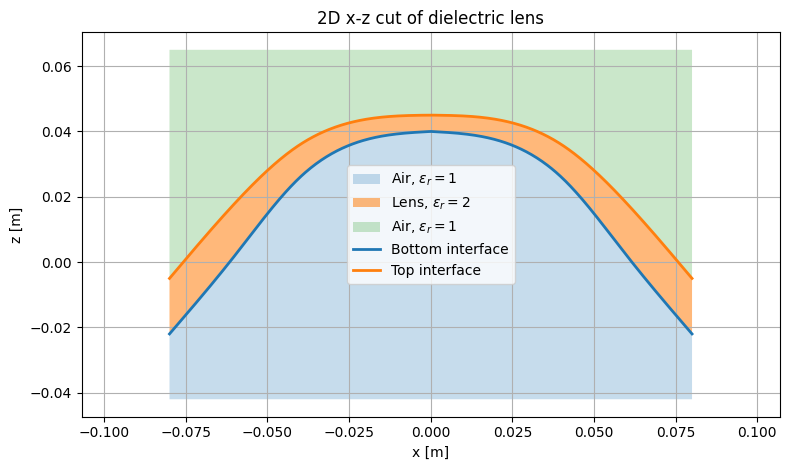

In [30]:
plot_lens_xz_cut(
    surf_bottom=surf1,
    surf_top=surf2,
    x_max=0.08
)

In [31]:
#scan_dir = np.array([0.0, 0.0, 1.0])
scan_dir = scan_dir_from_angles(theta_deg=20, phi_deg=0)

debug_reverse_ray_path(
    elem=array.elements[len(array.elements) // 2],
    lens=lens,
    wavelength=wavelength,
    scan_dir=scan_dir,
    ref_plane_z=0.040,
    t_max=1.0
)

Start point: [ 0.00499654 -0.03497579  0.04      ]
Start direction: [-0.34202014 -0.         -0.93969262]

Interface 0: lens_top_4pts
Hit point: [ 0.0045368  -0.03497579  0.03873686]
Normal: [ 0.05833622 -0.44973475  0.89125503]
Incident direction: [-0.34202014 -0.         -0.93969262]
n1: 1.0
n2: 1.7320508075688772
Transmitted direction: [-0.2242884   0.20678789 -0.95233055]

Interface 1: lens_bottom_4pts
Hit point: [ 0.00277472 -0.0333512   0.03125507]
Normal: [ 0.04639651 -0.55767041  0.82876479]
Incident direction: [-0.2242884   0.20678789 -0.95233055]
n1: 1.7320508075688772
n2: 1.0
Transmitted direction: [-0.34813499 -0.12675303 -0.92883567]

Ray crossed all reverse interfaces.


Number of reverse rays arriving to z=0: 864
Rays in Oxz plane: 444


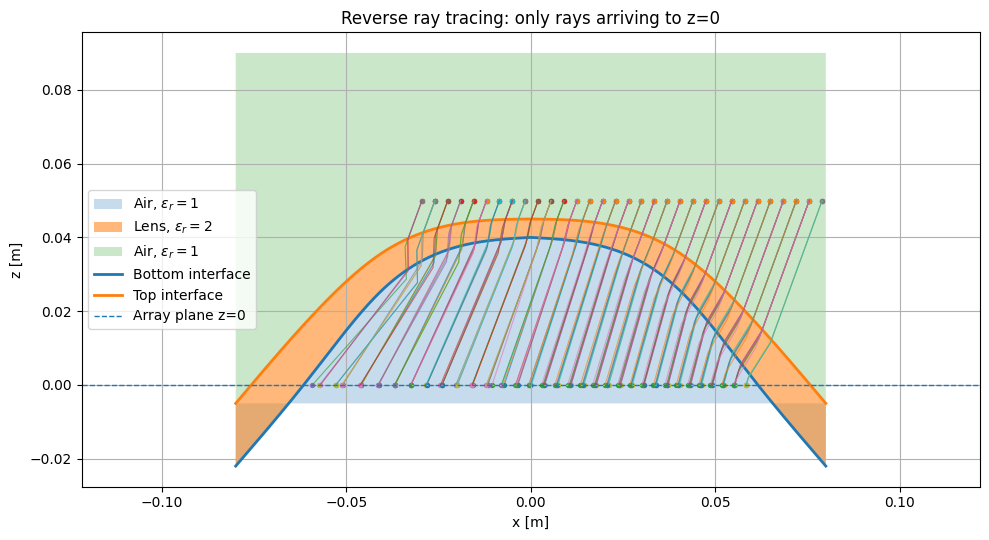

In [32]:
#scan_dir = np.array([0.0, 0.0, 1.0])
#scan_dir = scan_dir_from_angles(theta_deg=30, phi_deg=0)

reverse_grid = compute_reverse_ray_paths_from_ref_grid(
    lens=lens,
    wavelength=wavelength,
    scan_dir=scan_dir,
    ref_plane_z=0.05,
    x_range=(-0.04, 0.1),
    y_range=(-0.08, 0.08),
    nx=41,
    ny=41,
    t_max=1.0,
    target_z=0.0
)

reverse_paths = reverse_grid["paths"]
arrival_points = reverse_grid["arrival_points"]

print("Number of reverse rays arriving to z=0:", len(reverse_paths))

ray_paths_oxz = keep_rays_in_oxz_plane(
    reverse_grid["paths"],
    y_tol=3e-2
)

print("Rays in Oxz plane:", len(ray_paths_oxz))

plot_lens_xz_cut_with_reverse_rays(
    surf_bottom=surf1,
    surf_top=surf2,
    ray_paths=ray_paths_oxz,
    x_max=0.08,
    max_rays_to_plot=200
)

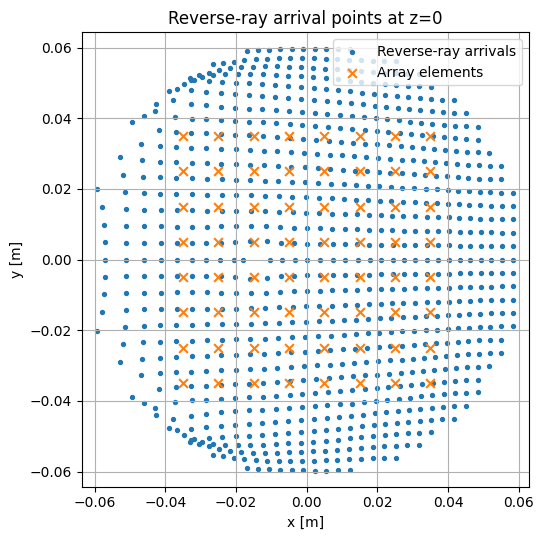

In [33]:
plt.figure(figsize=(5.5, 5.5))

plt.scatter(
    arrival_points[:, 0],
    arrival_points[:, 1],
    s=8,
    label="Reverse-ray arrivals"
)

array_pos = array.positions()

plt.scatter(
    array_pos[:, 0],
    array_pos[:, 1],
    s=40,
    marker="x",
    label="Array elements"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.xlim([-0.1, 0.1])
plt.ylim([-0.1, 0.1])
plt.title("Reverse-ray arrival points at z=0")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
phases, grad_x, grad_y, valid, arrivals, reverse_paths_angle = reverse_phase_from_arrival_angles(
    array=array,
    lens=lens,
    wavelength=wavelength,
    scan_dir=scan_dir,
    ref_plane_z=0.05,
    x_range=(-0.08, 0.08),
    y_range=(-0.08, 0.08),
    nx=51,
    ny=51,
    t_max=1.0,
    target_z=0.0,
    k_nearest=8,
    max_radius=1.0 * wavelength,
    neighbor_radius=None,
    reference_index=0,
    verbose=True
)

print("Phase matrix from arrival-angle strategy [rad]:")
print(phases.reshape(8, 8))

Reverse-angle phase assignment
--------------------------------
Reverse rays arriving to z=0: 1186
Valid elements: 64 / 64
Gradient x range: 80.40977928452503 145.76743955165057
Gradient y range: -51.62297343372012 51.6229734337201
Phase matrix from arrival-angle strategy [rad]:
[[ 4.69265271e-15  4.22576867e-01  6.79711413e-01  7.99293770e-01
   7.99293770e-01  6.79711413e-01  4.22576867e-01 -2.84217094e-14]
 [ 1.36976224e+00  1.73298896e+00  1.96099213e+00  2.07787931e+00
   2.07787931e+00  1.96099213e+00  1.73298896e+00  1.36976224e+00]
 [ 2.58502832e+00  2.90741273e+00  3.11290183e+00 -3.05078410e+00
  -3.05078410e+00  3.11290183e+00  2.90741273e+00  2.58502832e+00]
 [-2.60011750e+00 -2.30702733e+00 -2.11960345e+00 -2.02422393e+00
  -2.02422393e+00 -2.11960345e+00 -2.30702733e+00 -2.60011750e+00]
 [-1.58875697e+00 -1.31810861e+00 -1.14620902e+00 -1.06560419e+00
  -1.06560419e+00 -1.14620902e+00 -1.31810861e+00 -1.58875697e+00]
 [-6.45298174e-01 -3.88874813e-01 -2.28679024e-01 -1.52

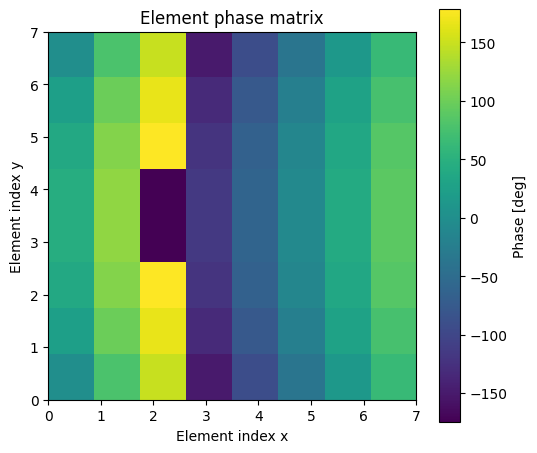

In [35]:
plot_element_phase_matrix_deg(
    phases,
    nx=8,
    ny=8
)

Total launched rays: 78400
Failed in lens: 0
Rejected dz≈0: 0
Rejected aperture behind ray: 0
Valid aperture rays: 78400
Aperture samples: 78400


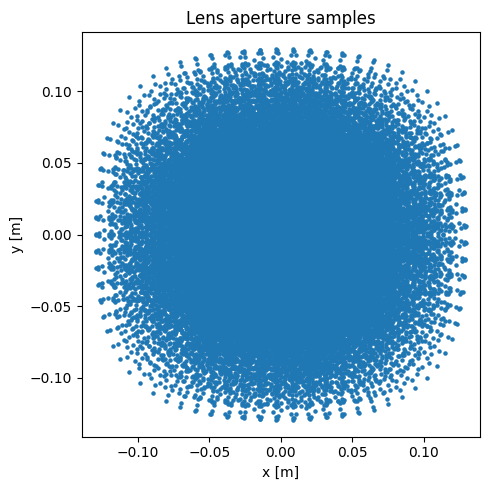

In [36]:
ap_data = direct_ray_tracing_to_aperture(
    array=array,
    lens=lens,
    aperture_z=0.05,
    wavelength=wavelength,
    n_theta=25,
    n_phi=49,
    t_max=1.0,
    verbose=True
)

print("Aperture samples:", len(ap_data["points"]))

if len(ap_data["points"]) == 0:
    raise RuntimeError("No rays reached the aperture.")

plot_aperture_points(
    ap_data["points"],
    title="Lens aperture samples"
)

In [37]:
tri = build_ray_tubes(ap_data)

print("Number of ray tubes:", len(tri.simplices))

Number of ray tubes: 150580


In [38]:
rt_fields = compute_ray_tube_fields(
    ap_data,
    tri,
    aperture_normal=np.array([0.0, 0.0, 1.0])
)

print("Aperture field samples:", len(rt_fields["barycenters"]))

Aperture field samples: 150580


In [39]:
currents = aperture_fields_and_currents(
    rt_fields,
    eta=eta0,
    aperture_normal=np.array([0.0, 0.0, 1.0]),
    pol="y"
)

In [40]:
U, V, E_ff, mask = far_field_po(
    currents,
    wavelength=wavelength,
    nu=61,
    nv=61
)

db = normalize_db(E_ff)

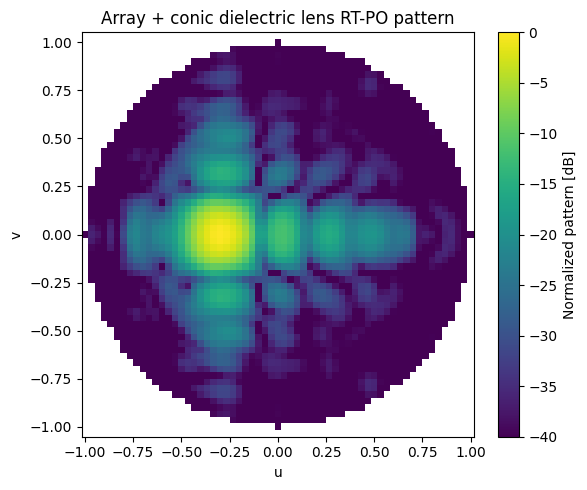

In [41]:
plot_uv_pattern(
    U,
    V,
    db,
    mask,
    title="Array + conic dielectric lens RT-PO pattern"
)

In [42]:
def plot_theta_cut(U, V, db, plane="xz", title=None):
    """
    Plot radiation pattern vs theta (degrees).

    plane:
        "xz" → φ = 0 → v = 0
        "yz" → φ = 90° → u = 0
    """

    if plane == "xz":
        # v = 0
        idx = np.argmin(np.abs(V[:, 0]))
        u = U[idx, :]
        pattern = db[idx, :]

        theta = np.rad2deg(np.arcsin(np.clip(u, -1, 1)))
        label = "φ = 0° (x–z plane)"

    elif plane == "yz":
        # u = 0
        idx = np.argmin(np.abs(U[0, :]))
        v = V[:, idx]
        pattern = db[:, idx]

        theta = np.rad2deg(np.arcsin(np.clip(v, -1, 1)))
        label = "φ = 90° (y–z plane)"

    else:
        raise ValueError("plane must be 'xz' or 'yz'")

    valid = np.isfinite(pattern)

    plt.figure(figsize=(7, 4))
    plt.plot(theta[valid], pattern[valid], linewidth=2)

    plt.xlabel("θ (degrees)")
    plt.ylabel("Normalized pattern [dB]")
    plt.title(title or f"Theta cut ({label})")
    plt.grid(True)
    plt.ylim(-40, 0)
    plt.xlim(-90, 90)
    plt.tight_layout()
    plt.show()

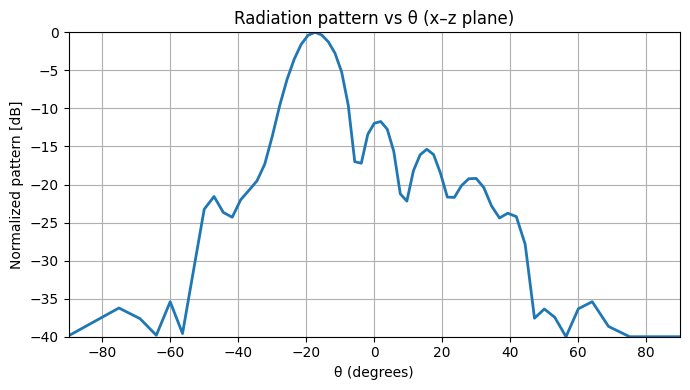

In [43]:
plot_theta_cut(
    U,
    V,
    db,
    plane="xz",
    title="Radiation pattern vs θ (x–z plane)"
)

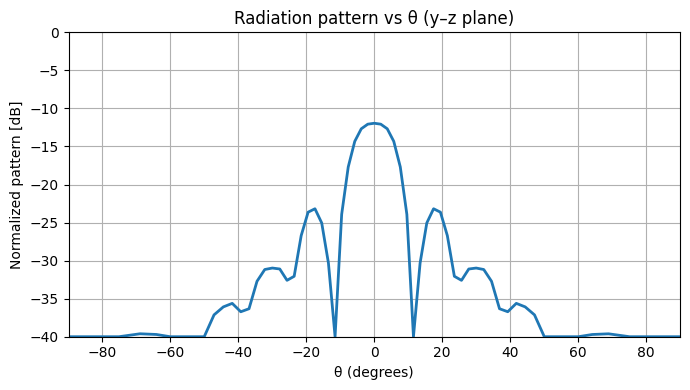

In [44]:
plot_theta_cut(
    U,
    V,
    db,
    plane="yz",
    title="Radiation pattern vs θ (y–z plane)"
)